# Urban Street Food Vendor Survival Project



### Step 1: Setup and Data Loading


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from the Colab file explorer
df = pd.read_csv('/content/UrbanStreetFoodVendor/urban_street_food_vendor_survival_dataset.csv')

# Display the shape (number of rows and columns) and the first 5 rows
print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (22000, 20)


,vendor_id,city,zone_type,vendor_age_years,years_in_business,food_category,license_status,avg_daily_revenue_inr,avg_daily_customers,monthly_stall_rent_inr,num_helpers,hours_open_per_day,competition_within_100m,monthly_health_inspection_score,had_fine_last_year,avg_monthly_rainfall_mm,season_of_observation,has_online_presence,customer_complaint_rate,vendor_survived
0,VSF-00001,Delhi,Industrial,34.0,10.98,Chinese,Licensed,332.20,10.0,0.00,1,10.00,4.0,65.00,0.0,103.08,Winter,0.0,0.12,1
1,VSF-00002,Kochi,University Area,33.0,5.53,Chaat,Licensed,3138.90,180.0,2112.10,1,6.42,3.0,NaN,1.0,350.00,Monsoon,1.0,0.22,1
2,VSF-00003,Hyderabad,Industrial,48.0,2.70,Desserts & Sweets,Licensed,1626.36,67.0,5487.75,3,11.80,0.0,NaN,0.0,66.64,Post-Monsoon,0.0,0.09,0
3,VSF-00004,Bengaluru,Transit Hub,NaN,9.77,Beverages,Licensed,3592.98,171.0,1960.79,3,12.53,NaN,36.38,1.0,107.30,Post-Monsoon,1.0,0.10,1
4,VSF-00005,Delhi,Transit Hub,51.0,21.24,South Indian,Licensed,2418.07,105.0,2720.82,4,6.07,5.0,71.05,0.0,166.57,Monsoon,0.0,0.08,0


### Step 2: NumPy Array Manipulation & Math Computations


In [ ]:
# 1. Array Manipulation: Extract revenue and customers as NumPy arrays
# We use .dropna() to remove any missing values before doing math
revenue_array = df['avg_daily_revenue_inr'].dropna().to_numpy()
customers_array = df['avg_daily_customers'].dropna().to_numpy()

# 2. Mathematical Computations
mean_revenue = np.mean(revenue_array)
max_revenue = np.max(revenue_array)
median_customers = np.median(customers_array)

print(f"Mean Daily Revenue: ₹{mean_revenue:.2f}")
print(f"Max Daily Revenue: ₹{max_revenue:.2f}")
print(f"Median Daily Customers: {median_customers}")

# 3. Logical Operations (Masking)
# Find how many vendors make strictly ABOVE average revenue
high_earner_mask = revenue_array > mean_revenue
num_high_earners = np.sum(high_earner_mask)
print(f"\nNumber of vendors earning above average: {num_high_earners}")

# 4. Mathematical Transformation (Broadcasting)
# Calculate a hypothetical 10% inflation adjustment on all revenues at once
adjusted_revenue = revenue_array * 1.10
print(f"\nFirst 5 Original Revenues: {revenue_array[:5]}")
print(f"First 5 Adjusted Revenues (10% increase): {adjusted_revenue[:5]}")

Mean Daily Revenue: ₹2391.24
Max Daily Revenue: ₹39997.33
Median Daily Customers: 74.0

Number of vendors earning above average: 5008

First 5 Original Revenues: [ 332.2  3138.9  1626.36 3592.98 2418.07]
First 5 Adjusted Revenues (10% increase): [ 365.42  3452.79  1788.996 3952.278 2659.877]


### Step 3: Data Cleaning and Preprocessing
**Objective:** Handle non-random missing values, and clean structural issues in categorical data using Pandas.

In [ ]:
# Create a copy of the original dataframe to keep the raw data safe
df_clean = df.copy()

# 1. Check for missing values before cleaning
print("Missing values BEFORE cleaning:\n", df_clean.isnull().sum().sort_values(ascending=False).head(6))
print("-" * 50)

# 2. Handle Missing Inspection Scores
# Strategy: Fill missing scores with the median score of that specific city
df_clean['monthly_health_inspection_score'] = df_clean.groupby('city')['monthly_health_inspection_score'].transform(lambda x: x.fillna(x.median()))

# 3. Handle Missing Revenue
# Strategy: Fill missing revenue with the overall median revenue
df_clean['avg_daily_revenue_inr'] = df_clean['avg_daily_revenue_inr'].fillna(df_clean['avg_daily_revenue_inr'].median())

# 4. Clean text strings (Categorical Data)
# Standardize city names and food categories to Title Case to fix any spelling case mismatches
df_clean['city'] = df_clean['city'].str.title()
df_clean['food_category'] = df_clean['food_category'].str.title()

# 5. Verify the cleaning
print("Missing inspection scores AFTER cleaning:", df_clean['monthly_health_inspection_score'].isnull().sum())
print("Missing revenue AFTER cleaning:", df_clean['avg_daily_revenue_inr'].isnull().sum())

Missing values BEFORE cleaning:
 monthly_health_inspection_score    7759
customer_complaint_rate            2420
avg_daily_revenue_inr              1938
avg_daily_customers                1253
monthly_stall_rent_inr             1110
years_in_business                  1037
dtype: int64
--------------------------------------------------
Missing inspection scores AFTER cleaning: 0
Missing revenue AFTER cleaning: 0


### Step 4: Data Aggregation


In [ ]:
# 1. Aggregation: Survival rate and average revenue by City
city_insights = df_clean.groupby('city').agg(
    total_vendors=('vendor_id', 'count'),
    survival_rate=('vendor_survived', 'mean'),  # The mean of 1s and 0s gives the percentage!
    avg_revenue=('avg_daily_revenue_inr', 'mean')
).reset_index()

# Sort by survival rate (highest to lowest)
city_insights = city_insights.sort_values(by='survival_rate', ascending=False)
print("--- City Survival Insights ---")
display(city_insights)

# 2. Aggregation: Does having a license matter?
license_impact = df_clean.groupby('license_status').agg(
    survival_rate=('vendor_survived', 'mean'),
    avg_revenue=('avg_daily_revenue_inr', 'mean')
).reset_index()

print("\n--- Impact of License Status ---")
display(license_impact)

--- City Survival Insights ---


,city,total_vendors,survival_rate,avg_revenue
3,Jaipur,1927,0.455631,2313.532459
4,Kochi,1549,0.438993,2357.408908
0,Bengaluru,3279,0.437328,2251.235108
7,Pune,2208,0.432971,2380.602336
2,Hyderabad,2667,0.424822,2274.331348
6,Mumbai,4392,0.421448,2366.560198
5,Lucknow,1936,0.418905,2193.710574
1,Delhi,4042,0.401039,2339.821598



--- Impact of License Status ---


,license_status,survival_rate,avg_revenue
0,Expired,0.338367,2425.142762
1,Licensed,0.476621,2327.592927
2,Pending Renewal,0.471704,2234.915954
3,Unlicensed,0.336871,2339.462242


PERFORMING EDA

/tmp/ipykernel_435/1255810542.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='license_status', y='vendor_survived', palette='viridis', ax=axes[0, 1])


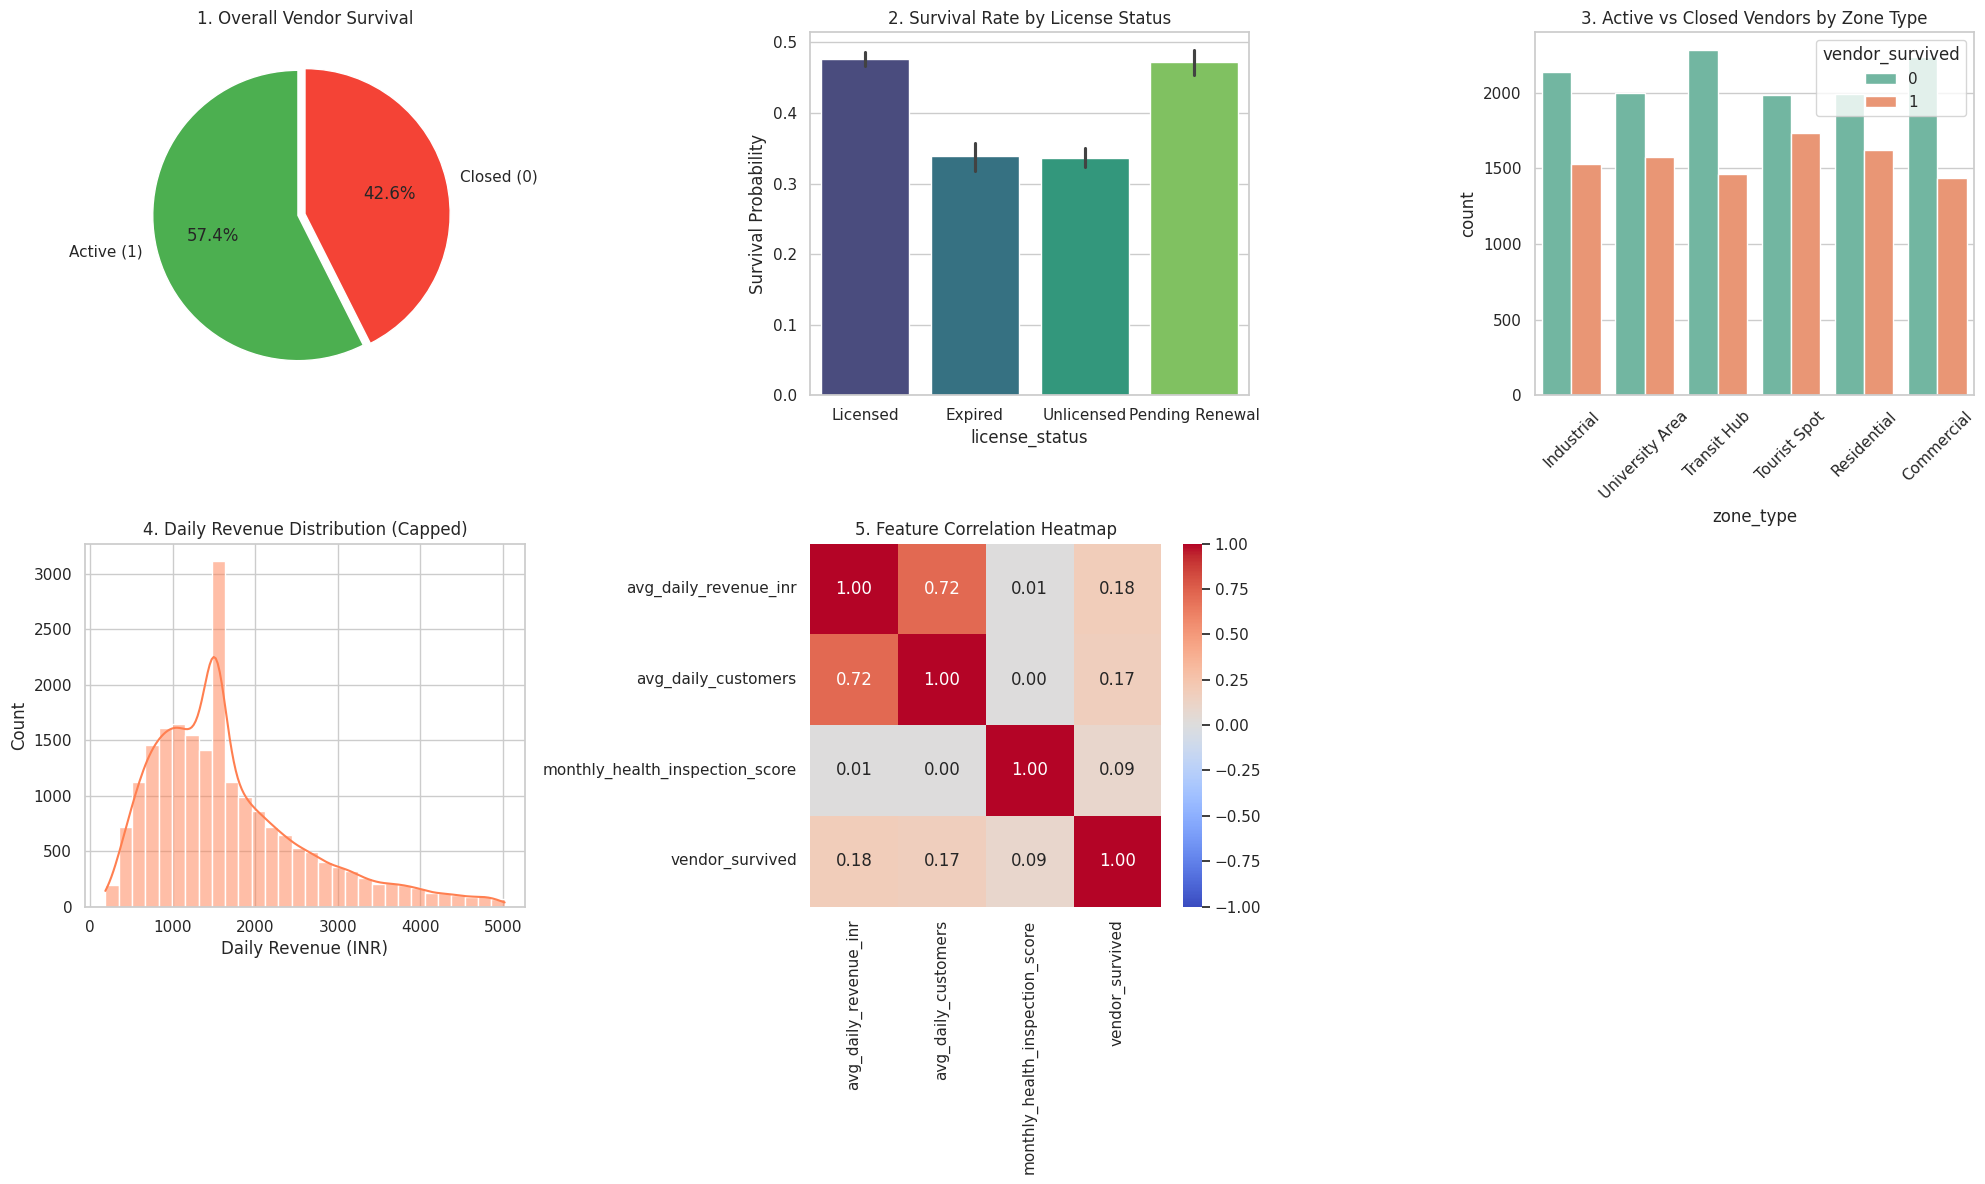

In [ ]:
# Set general Seaborn style for better aesthetics
sns.set_theme(style="whitegrid")

# Create a figure with a 2x3 grid (we will hide the last empty subplot)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# --- Chart 1: Pie Chart (Overall Survival Distribution) ---
survival_counts = df_clean['vendor_survived'].value_counts()
axes[0, 0].pie(survival_counts, labels=['Active (1)', 'Closed (0)'], autopct='%1.1f%%',
               colors=['#4CAF50', '#F44336'], startangle=90, explode=[0.05, 0])
axes[0, 0].set_title('1. Overall Vendor Survival')

# --- Chart 2: Bar Plot (Survival by License Status) ---
sns.barplot(data=df_clean, x='license_status', y='vendor_survived', palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title('2. Survival Rate by License Status')
axes[0, 1].set_ylabel('Survival Probability')

# --- Chart 3: Count Plot (Vendors by Zone Type) ---
sns.countplot(data=df_clean, x='zone_type', hue='vendor_survived', palette='Set2', ax=axes[0, 2])
axes[0, 2].set_title('3. Active vs Closed Vendors by Zone Type')
axes[0, 2].tick_params(axis='x', rotation=45)

# --- Chart 4: Histogram (Revenue Distribution) ---
# We cap the revenue at the 95th percentile just for the graph so extreme outliers don't stretch the plot
revenue_cap = df_clean['avg_daily_revenue_inr'].quantile(0.95)
filtered_revenue = df_clean[df_clean['avg_daily_revenue_inr'] < revenue_cap]

sns.histplot(filtered_revenue['avg_daily_revenue_inr'], bins=30, kde=True, color='coral', ax=axes[1, 0])
axes[1, 0].set_title('4. Daily Revenue Distribution (Capped)')
axes[1, 0].set_xlabel('Daily Revenue (INR)')

# --- Chart 5: Heatmap (Correlation Matrix) ---
# Select a few numerical columns to see how they correlate with survival
numerical_cols = ['avg_daily_revenue_inr', 'avg_daily_customers', 'monthly_health_inspection_score', 'vendor_survived']
corr_matrix = df_clean[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1], vmin=-1, vmax=1)
axes[1, 1].set_title('5. Feature Correlation Heatmap')

# Hide the 6th empty subplot (bottom right) since we only have 5 charts
fig.delaxes(axes[1, 2])

# Adjust spacing so labels don't overlap
plt.tight_layout()
plt.show()